Found 368 candidate Landsat scenes
Using EPSG:32721 for projection
Filtering scenes: Cloud < 20%, Coverage >= 70%...
Computing local cloud stats...
[########################################] | 100% Completed | 5.06 ss
Retained 293 scenes after local filtering (max 20%)
Filtered to 262 scenes within 06-01 to 10-31
Compositing data over Y using median...


c:\Users\darey\AppData\Local\pypoetry\Cache\virtualenvs\ex7-Kjj2zdUm-py3.11\Lib\site-packages\xarray\groupers.py:543: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


[########################################] | 100% Completed | 88.14 s
NBR datacube: ('time', 'y', 'x')  shape=(42, 167, 167)
NBR datacube: shape=(42, 167, 167)  time steps=42
Years: [1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
Values: [0.728 0.713 0.75  0.71  0.662 0.712 0.756 0.744 0.681 0.697 0.743 0.724
 0.713 0.701 0.627 0.655 0.715 0.725 0.734 0.054 0.362 0.681 0.638 0.513
 0.603 0.56  0.636 0.655 0.626 0.727 0.42  0.363 0.318 0.257 0.212 0.209
 0.221 0.225 0.247 0.248 0.227 0.245]
Vertex years : [1984 2002 2003 2005 2007 2013 2019 2025]
Segments     : 7
RMSE         : 0.0688


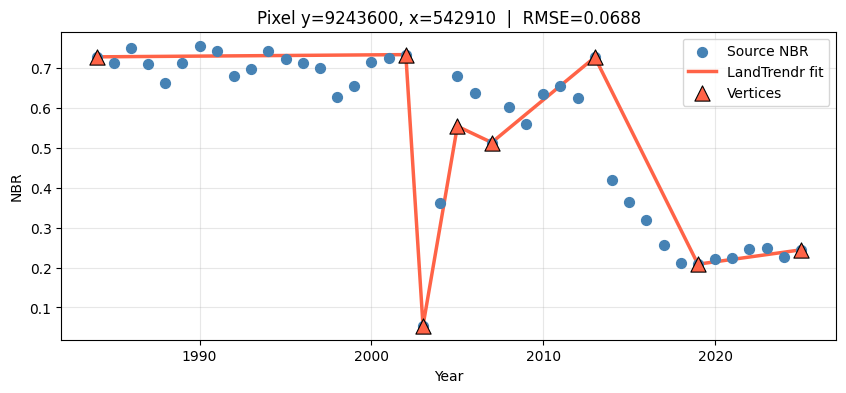

LandTrendr:   0%|          | 0/27889 [00:00<?, ?px/s]

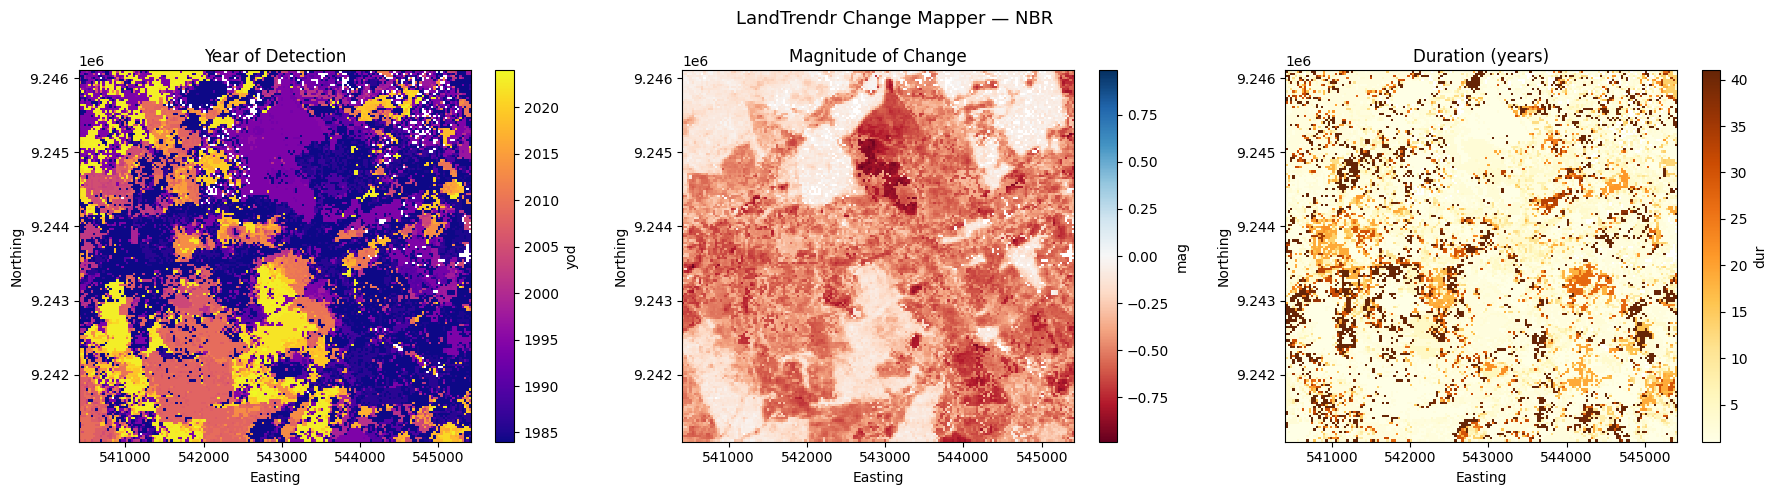

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from space_time_deepsearch.core import SpaceTimeDeepSearch
from space_time_deepsearch.temporal._landtrendr_core import landtrendr_pixel
import math


def get_500m_bbox(lat, lon):
    """
    Returns a 500m bounding box (approx. 250m offset from center).
    Format: (min_lon, min_lat, max_lon, max_lat)
    """
    # Earth's radius in meters
    R = 6378137
    
    # Coordinate offsets in radians
    d_lat = 2500 / R
    d_lon = 2500 / (R * math.cos(math.pi * lat / 180))
    
    # Convert offsets to degrees
    offset_lat = d_lat * 180 / math.pi
    offset_lon = d_lon * 180 / math.pi
    
    return (
        round(lon - offset_lon, 5), # min_lon
        round(lat - offset_lat, 5), # min_lat
        round(lon + offset_lon, 5), # max_lon
        round(lat + offset_lat, 5)  # max_lat
    )

def run_workflow(bbox):

    stds = SpaceTimeDeepSearch(bbox)

    s2 = stds.get_landsat(
        start_date="1984-01-01",
        end_date="2026-01-01",
        cloud_cover_max=20,
        min_coverage=70,
        mask_clouds=True,
        composite_period="Y",
        composite_start="06-01",
        composite_end="10-31",
        add_ndvi=True,
        add_nbr=True,
    )

    # Select NBR band → (time, y, x)
    ndvi = s2.sel(band="NBR", drop=True)
    print(f"NBR datacube: {ndvi.dims}  shape={ndvi.shape}")
    print(f"NBR datacube: shape={ndvi.shape}  time steps={len(ndvi.time)}")

    # Pick a pixel (centre of the image)
    cy = float(ndvi.y.values[len(ndvi.y) // 2])
    cx = float(ndvi.x.values[len(ndvi.x) // 2])
    pixel = ndvi.sel(y=cy, x=cx, method="nearest")

    # Extract numpy arrays
    if np.issubdtype(pixel.time.dtype, np.datetime64):
        years = pixel.time.dt.year.values.astype(np.int32)
    else:
        years = pixel.time.values.astype(np.int32)

    values = pixel.values.astype(np.float64)

    print(f"Years: {years}")
    print(f"Values: {np.round(values, 3)}")

    # Run LandTrendr on this single pixel
    fitted, is_vertex, rmse = landtrendr_pixel(years, values,
        max_segments=6,
        spike_threshold=0.9,
        vertex_count_overshoot=3,
        prevent_one_year_recovery=True,
        recovery_threshold=0.25,
        pval_threshold=0.25,
        best_model_proportion=0.75,
        min_observations_needed=6,
    )

    print(f"Vertex years : {years[is_vertex]}")
    print(f"Segments     : {np.sum(is_vertex) - 1}")
    print(f"RMSE         : {rmse:.4f}")

    # --- Static single-pixel plot ---
    plt.figure(figsize=(10, 4))
    plt.scatter(years, values, color="steelblue", s=50, zorder=3, label="Source NBR")
    plt.plot(years, fitted, color="tomato", lw=2.5, zorder=2, label="LandTrendr fit")
    plt.scatter(years[is_vertex], fitted[is_vertex], marker="^", color="tomato",
                s=120, edgecolors="black", lw=0.8, zorder=4, label="Vertices")
    plt.xlabel("Year")
    plt.ylabel("NBR")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.title(f"Pixel y={cy:.0f}, x={cx:.0f}  |  RMSE={rmse:.4f}")
    plt.show()

    # --- Run LandTrendr on full datacube ---
    from space_time_deepsearch.temporal import LandTrendrParams

    lt_result = stds.run_landtrendr(
        ndvi,
        composite_to_annual=False,
        params=LandTrendrParams(
            max_segments=6,
            spike_threshold=0.9,
            vertex_count_overshoot=3,
            prevent_one_year_recovery=False,
            recovery_threshold=0.25,
            pval_threshold=0.05,
            best_model_proportion=0.75,
            min_observations_needed=6,
        ),
    )

    # --- Extract change map ---
    change = stds.extract_change_map(
        lt_result,
        change_type="greatest",
        delta_filter="loss",
    )

    # --- Static change map plots ---
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    change["yod"].plot(ax=axes[0], cmap="plasma",    add_colorbar=True)
    axes[0].set_title("Year of Detection")

    change["mag"].plot(ax=axes[1], cmap="RdBu",      center=0, add_colorbar=True)
    axes[1].set_title("Magnitude of Change")

    change["dur"].plot(ax=axes[2], cmap="YlOrBr",    add_colorbar=True)
    axes[2].set_title("Duration (years)")

    for ax in axes:
        ax.set_xlabel("Easting")
        ax.set_ylabel("Northing")

    plt.suptitle("LandTrendr Change Mapper — NBR", fontsize=13)
    plt.tight_layout()
    plt.show()

    # Return results for the interactive inspector
    return stds, lt_result, change

# Run the workflow
bbox = get_500m_bbox(-6.84313, -56.61152)
stds, lt_result, change = run_workflow(bbox)

In [2]:
# ── Interactive LandTrendr Inspector ──────────────────────────────────────────
# Click on any pixel in the YOD / Magnitude / Duration maps to see its
# source values, fitted trajectory, and detected vertices.
# Use the checkboxes to toggle map layers on/off.

from space_time_deepsearch.temporal import inspect_landtrendr

inspector = inspect_landtrendr(lt_result, change)
inspector.panel()

BokehModel(combine_events=True, render_bundle={'docs_json': {'b20e645a-c7fe-4ee8-9ff1-a71998f4e748': {'version…

Found 368 candidate Landsat scenes
Using EPSG:32721 for projection
Filtering scenes: Cloud < 20%, Coverage >= 70%...
Computing local cloud stats...
[########################################] | 100% Completed | 5.86 sms
Retained 293 scenes after local filtering (max 20%)
Filtered to 262 scenes within 06-01 to 10-31
Compositing data over Y using median...


c:\Users\darey\AppData\Local\pypoetry\Cache\virtualenvs\ex7-Kjj2zdUm-py3.11\Lib\site-packages\xarray\groupers.py:543: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


[########################################] | 100% Completed | 32.82 s
NDVI datacube: ('time', 'y', 'x')  shape=(42, 167, 167)

NDVI datacube: shape=(42, 167, 167)  time steps=42
Years: [1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
Values: [0.728 0.713 0.75  0.71  0.662 0.712 0.756 0.744 0.681 0.697 0.743 0.724
 0.713 0.701 0.627 0.655 0.715 0.725 0.734 0.054 0.362 0.681 0.638 0.513
 0.603 0.56  0.636 0.655 0.626 0.727 0.42  0.363 0.318 0.257 0.212 0.209
 0.221 0.225 0.247 0.248 0.227 0.245]
Years        : [1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
Source NDVI  : [0.728 0.713 0.75  0.71  0.662 0.712 0.756 0.744 0.681 0.697 0.743 0.724
 0.713 0.701 0.627 

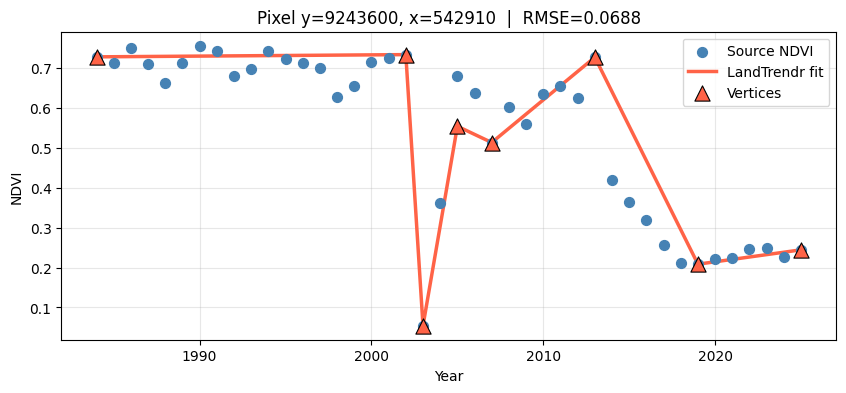

LandTrendr:   0%|          | 0/27889 [00:00<?, ?px/s]

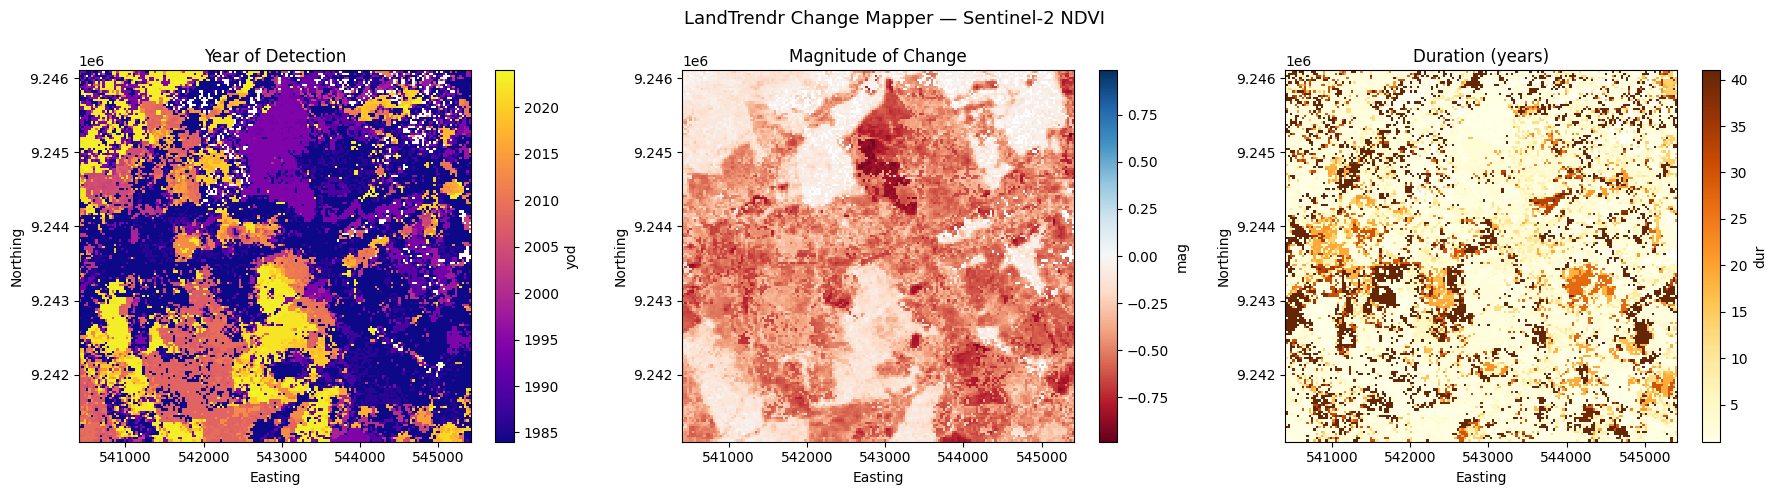

In [20]:
# Example for your coordinates: [2.69271, -74.06598]
bbox = get_500m_bbox(-6.84313, -56.61152)
run_workflow(bbox)

Found 385 candidate Landsat scenes
Using EPSG:32721 for projection
Filtering scenes: Cloud < 20%, Coverage >= 70%...
Computing local cloud stats...
[########################################] | 100% Completed | 4.44 sms
Retained 335 scenes after local filtering (max 20%)
Compositing data over Y using median...


c:\Users\darey\AppData\Local\pypoetry\Cache\virtualenvs\ex7-Kjj2zdUm-py3.11\Lib\site-packages\xarray\groupers.py:543: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  self.index_grouper = pd.Grouper(


[########################################] | 100% Completed | 27.92 s
NDVI datacube: ('time', 'y', 'x')  shape=(42, 168, 169)

NDVI datacube: shape=(42, 168, 169)  time steps=42
Years: [1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
Values: [0.487 0.759 0.8   0.81  0.658 0.645 0.467 0.781 0.449 0.596 0.606 0.505
 0.475 0.364 0.582 0.601 0.52  0.541 0.71  0.644 0.489 0.561 0.601 0.541
 0.551 0.636 0.532 0.655 0.502 0.632 0.65  0.615 0.696 0.625 0.628 0.674
 0.678 0.521 0.67  0.605 0.468 0.496]
Years        : [1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011
 2012 2013 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024 2025]
Source NDVI  : [0.487 0.759 0.8   0.81  0.658 0.645 0.467 0.781 0.449 0.596 0.606 0.505
 0.475 0.364 0.582 

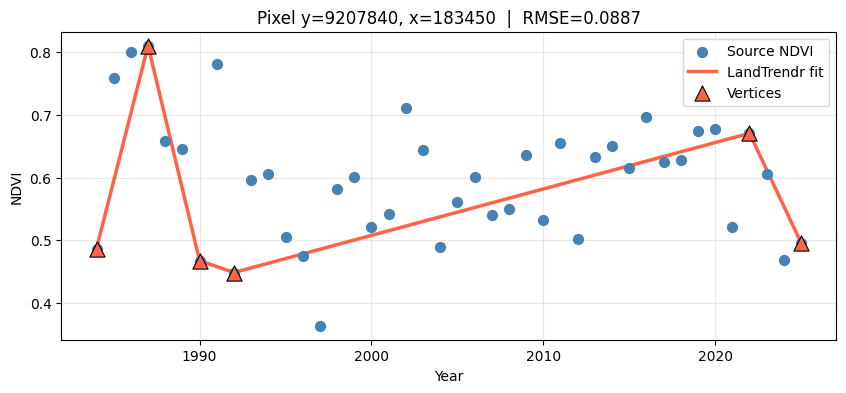

LandTrendr:   0%|          | 0/28392 [00:00<?, ?px/s]

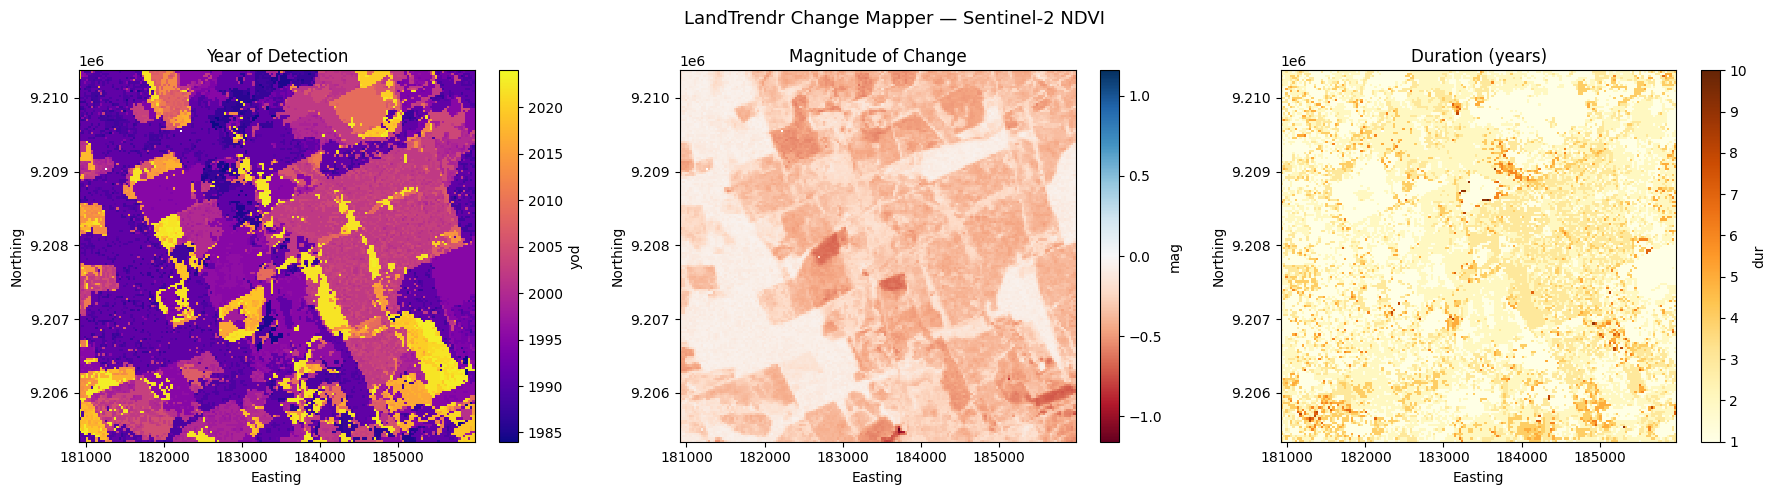

: 

In [ ]:
# Example for your coordinates: [2.69271, -74.06598]
bbox = get_500m_bbox( -7.15769930139025, -59.86555255643998)
run_workflow(bbox)

In [13]:
import ee
from ltgee import LandTrendr, LandsatComposite, LtCollection
from datetime import date
# Initialize access to Google's EE servers
ee.Initialize()

# Initialize variables for LandTrendr algorithm
composite_params = {
    "start_date": date(1985, 6,1),
    "end_date": date(2017, 9,1),
    "area_of_interest": ee.Geometry({
        'type': 'Polygon',
        'coordinates': [
            [
                [-122.37202331327023,44.62585686599272],
                [-122.26765319608273,44.62585686599272],
                [-122.26765319608273,44.696185837887384],
                [-122.37202331327023,44.696185837887384],
                [-122.37202331327023,44.62585686599272],
                ]
            ]
    }),
    "mask_labels": ['cloud', 'shadow', 'snow', 'water'],
    "debug": True
}
lt_collection_params = {
        "sr_collection": LandsatComposite(**composite_params),
        # "sr_collection": composite_params, # - you may also just pass in your own collection or the params directly. Note: in the former, some methods in the class may not work.
        "index": 'NBR',
        "ftv_list": ['TCB', 'TCG', 'TCW', 'NBR'],
}
lt_params = {
    "lt_collection": LtCollection(**lt_collection_params),
    # "lt_collection": lt_collection_params, # - you may also just pass in your own collection or the params directly. Note: in the former, some methods in the class may not work.
    "run_params": {
            "maxSegments": 6,
            "spikeThreshold": 0.9,
            "vertexCountOvershoot":  3,
            "preventOneYearRecovery":  True,
            "recoveryThreshold":  0.25,
            "pvalThreshold":  .05,
            "bestModelProportion":  0.75,
            "minObservationsNeeded": 6,
        }
}

# Instantiating LandTrendr object. Note: The object will immediately request to run the algorithm on Google's servers.
lt = LandTrendr(**lt_params)

# Access resulting image using the getInfo attribute. LandTrendr is a sublass of ee.Image
print(lt.getInfo())

{'type': 'Image', 'bands': [{'id': 'LandTrendr', 'data_type': {'type': 'PixelType', 'precision': 'double', 'dimensions': 2}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'ftv_tcb_fit', 'data_type': {'type': 'PixelType', 'precision': 'double', 'dimensions': 1}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'ftv_tcg_fit', 'data_type': {'type': 'PixelType', 'precision': 'double', 'dimensions': 1}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'ftv_tcw_fit', 'data_type': {'type': 'PixelType', 'precision': 'double', 'dimensions': 1}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'ftv_nbr_fit', 'data_type': {'type': 'PixelType', 'precision': 'double', 'dimensions': 1}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}, {'id': 'rmse', 'data_type': {'type': 'PixelType', 'precision': 'double'}, 'crs': 'EPSG:4326', 'crs_transform': [1, 0, 0, 0, 1, 0]}]}


In [14]:
!pip install geeViz

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Using cached pywin32-311-cp311-cp311-win_amd64.whl.metadata (10 kB)
  Using cached rsa-4.9.1-py3-none-any.whl.metadata (5.6 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 2.1/2.1 MB 9.5 MB/s  0:00:00
Using cached pywin32-311-cp311-cp311-win_amd64.whl (9.5 MB)
Using cached rsa-4.9.1-py3-none-any.whl (34 kB)
  Created wheel for simpledbf: filename=simpledbf-0.2.6-py3-none-any.whl size=13927 sha256=1416908206e233c6acfd6d473b9dcd006a6c29f7edf23edc4590eb87c3e4b329
  Stored in directory: c:\users\darey\appdata\local\pip\cache\wheels\37\52\21\14be45b7c160488637e82d6a317f4379458bb4dd60be21d5fa
Succe


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [15]:
"""
   Copyright 2026 Ian Housman

   Licensed under the Apache License, Version 2.0 (the "License");
   you may not use this file except in compliance with the License.
   You may obtain a copy of the License at

       http://www.apache.org/licenses/LICENSE-2.0

   Unless required by applicable law or agreed to in writing, software
   distributed under the License is distributed on an "AS IS" BASIS,
   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.
   See the License for the specific language governing permissions and
   limitations under the License.
"""

# Example of how to visualize LandTrendr outputs using the Python visualization tools
# LANDTRENDR original paper: https://www.sciencedirect.com/science/article/pii/S0034425710002245
# LANDTRENDR in GEE paper: https://www.mdpi.com/2072-4292/10/5/691
# Takes pre-exported LT stack output and provides a visualization of loss and gain years, duration, and magnitude
# Also charts the LT output time series
####################################################################################################
import os, sys

sys.path.append(os.getcwd())

# Module imports
import geeViz.getImagesLib as gil
import geeViz.changeDetectionLib as cdl

ee = gil.ee
Map = gil.Map
Map.clearMap()
Map.port = 1234
####################################################################################################
# Define user parameters:

# Specify which years to look at
# Available years are 1984-2021
startYear = 1984
endYear = 2024

# Which property stores which band/index LandTrendr was run across
bandPropertyName = "band"

# Specify which bands to run across
# Set to None to run all available bands
# Available bands include: ['NBR', 'NDMI', 'NDSI', 'NDVI', 'blue', 'brightness', 'green', 'greenness', 'nir', 'red', 'swir1', 'swir2', 'tcAngleBG', 'wetness']
bandNames = None

# Specify if output is an array image or not
arrayMode = True
####################################################################################################
# Bring in LCMS LandTrendr outputs (see other examples that include LCMS final data)
lt = ee.ImageCollection("projects/lcms-tcc-shared/assets/CONUS/Base-Learners/LandTrendr-Collection")
print(
    "Available bands/indices:",
    lt.aggregate_histogram(bandPropertyName).keys().getInfo(),
)

lt_props = lt.first().toDictionary().getInfo()
print(lt_props)

# Convert stacked outputs into collection of fitted, magnitude, slope, duration, etc values for each year
# Divide by 10000 (0.0001) so values are back to original values (0-1 or -1-1)
lt_fit = cdl.batchSimpleLTFit(
    lt,
    startYear,
    endYear,
    bandNames,
    bandPropertyName,
    arrayMode,
    lt_props["maxSegments"],
    0.0001,
)

# Vizualize image collection for charting (opacity set to 0 so it will chart but not be visible)
Map.addLayer(lt_fit.select(["NBR_LT_fitted"]), {"opacity": 0}, "LT Fit TS")

# Visualize single year fitted landTrendr composite
# Set to only run if no bandNames are specified
if bandNames == None:
    # Get fitted bandnames
    fitted_bns = lt_fit.select([".*_fitted"]).first().bandNames()
    out_bns = fitted_bns.map(lambda bn: ee.String(bn).split("_").get(0))

    # Filter out next to last year
    lt_synth = lt_fit.select(fitted_bns, out_bns)
    # .filter(ee.Filter.calendarRange(endYear-1,endYear-1,'year')).first()
    gil.vizParamsFalse["reducer"] = ee.Reducer.lastNonNull()
    # Visualize as you would a composite
    Map.addLayer(lt_synth, gil.vizParamsFalse, "Synthetic Composite")


# Iterate across each band to look for areas of change
if bandNames == None:
    bandNames = ["NBR"]
for bandName in bandNames:
    # Do basic change detection with raw LT output
    ltt = lt.filter(ee.Filter.eq(bandPropertyName, bandName)).mosaic()
    ltt = cdl.multLT(ltt, cdl.changeDirDict[bandName] * 0.0001)

    lossMagThresh = -0.15
    lossSlopeThresh = -0.1
    gainMagThresh = 0.1
    gainSlopeThresh = 0.1
    slowLossDurationThresh = 3
    chooseWhichLoss = "largest"
    chooseWhichGain = "largest"
    howManyToPull = 1

    lossGainDict = cdl.convertToLossGain(
        ltt,
        format="arrayLandTrendr",
        lossMagThresh=lossMagThresh,
        lossSlopeThresh=lossSlopeThresh,
        gainMagThresh=gainMagThresh,
        gainSlopeThresh=gainSlopeThresh,
        slowLossDurationThresh=slowLossDurationThresh,
        chooseWhichLoss=chooseWhichLoss,
        chooseWhichGain=chooseWhichGain,
        howManyToPull=howManyToPull,
    )
    lossGainStack = cdl.LTLossGainExportPrep(lossGainDict, indexName=bandName, multBy=1)
    cdl.addLossGainToMap(
        lossGainStack,
        startYear,
        endYear,
        lossMagThresh - 0.7,
        lossMagThresh,
        gainMagThresh,
        gainMagThresh + 0.7,
    )
####################################################################################################
####################################################################################################
# View map
Map.setQueryDateFormat("YYYY")
Map.turnOnInspector()
Map.view()
####################################################################################################

Available bands/indices: ['NBR', 'NDMI', 'NDSI', 'NDVI', 'blue', 'brightness', 'green', 'greenness', 'nir', 'red', 'swir1', 'swir2', 'tcAngleBG', 'wetness']
{'band': 'NBR', 'bestModelProportion': 0.75, 'endJulian_firstPeriod': 273, 'endJulian_secondPeriod': 244, 'endYear': 2025, 'maxSegments': 9, 'minObservationsNeeded': 6, 'pvalThreshold': 0.05, 'recoveryThreshold': 0.25, 'spikeThreshold': 0.9, 'startJulian_firstPeriod': 152, 'startJulian_secondPeriod': 182, 'startYear': 1984, 'vertexCountOvershoot': 3}
Adding layer: LT Fit TS
Adding layer: Synthetic Composite
Converting LandTrendr from array output to Gain & Loss
Adding layer: LandTrendr NBR Loss Year
Adding layer: LandTrendr NBR Loss Magnitude
Adding layer: LandTrendr NBR Loss Duration
Adding layer: LandTrendr NBR Gain Year
Adding layer: LandTrendr NBR Gain Magnitude
Adding layer: LandTrendr NBR Gain Duration
Setting default query date format to: YYYY
Starting webmap
Using default refresh token for geeView
Starting local web server 

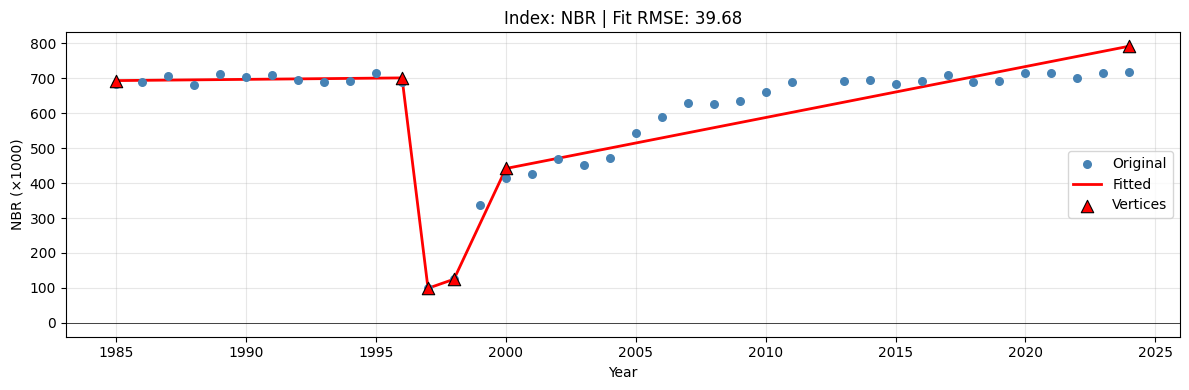

Vertex years: [1985 1996 1997 1998 2000 2024]
Vertex NBR:   [0.693 0.701 0.099 0.125 0.442 0.792]
RMSE: 39.68


In [19]:
"""
Corrected GEE LandTrendr pixel extraction for Oregon forest site.
Fixes: (1) apply C2 L2 scale factors, (2) rename L5/7 bands to match L8/9.
"""
import ee
import numpy as np
import matplotlib.pyplot as plt

ee.Initialize()

# ── Configuration ──
lon, lat = -122.8848, 43.7929
start_year, end_year = 1985, 2024
start_day, end_day = '06-15', '09-15'

run_params = {
    'maxSegments': 6,
    'spikeThreshold': 0.9,
    'vertexCountOvershoot': 3,
    'preventOneYearRecovery': True,
    'recoveryThreshold': 0.25,
    'pvalThreshold': 0.05,
    'bestModelProportion': 0.75,
    'minObservationsNeeded': 6,
}

# ── Helper functions ──

def apply_scale_factors(image):
    """Apply Landsat C2 L2 surface reflectance scale factors."""
    optical = image.select('SR_B.').multiply(0.0000275).add(-0.174)
    return image.addBands(optical, overwrite=True)

def mask_clouds(image):
    """Mask clouds, shadows, snow using QA_PIXEL."""
    qa = image.select('QA_PIXEL')
    mask = (qa.bitwiseAnd(1 << 3).eq(0)   # cloud shadow
            .And(qa.bitwiseAnd(1 << 4).eq(0))  # cloud
            .And(qa.bitwiseAnd(1 << 5).eq(0)))  # snow
    return image.updateMask(mask)

def rename_tm_bands(image):
    """Rename TM/ETM+ bands to match OLI naming convention.
    
    TM/ETM+: B1=Blue, B2=Green, B3=Red, B4=NIR, B5=SWIR1, B7=SWIR2
    OLI:     B2=Blue, B3=Green, B4=Red, B5=NIR, B6=SWIR1, B7=SWIR2
    """
    return image.select(
        ['SR_B1', 'SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B7', 'QA_PIXEL'],
        ['SR_B2', 'SR_B3', 'SR_B4', 'SR_B5', 'SR_B6', 'SR_B7', 'QA_PIXEL']
    )

def calc_nbr(image):
    """NBR = (NIR - SWIR2) / (NIR + SWIR2). Works after band renaming."""
    return image.normalizedDifference(['SR_B5', 'SR_B7']).rename('NBR')

# ── Build collection ──
point = ee.Geometry.Point([lon, lat])
aoi = point.buffer(3000)

# Landsat 5 TM — rename bands to OLI convention
lt5 = (ee.ImageCollection('LANDSAT/LT05/C02/T1_L2')
       .filterBounds(aoi)
       .map(rename_tm_bands)
       .map(mask_clouds)
       .map(apply_scale_factors))

# Landsat 7 ETM+ — pre SLC-off only, rename bands
lt7 = (ee.ImageCollection('LANDSAT/LE07/C02/T1_L2')
       .filterBounds(aoi)
       .filterDate('1999-01-01', '2003-05-31')
       .map(rename_tm_bands)
       .map(mask_clouds)
       .map(apply_scale_factors))

# Landsat 8 OLI — bands already in OLI convention
lt8 = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
       .filterBounds(aoi)
       .map(mask_clouds)
       .map(apply_scale_factors))

# Landsat 9 OLI-2
lt9 = (ee.ImageCollection('LANDSAT/LC09/C02/T1_L2')
       .filterBounds(aoi)
       .map(mask_clouds)
       .map(apply_scale_factors))

merged = lt5.merge(lt7).merge(lt8).merge(lt9)

# ── Build annual composites ──
images = []
for year in range(start_year, end_year + 1):
    date_start = f'{year}-{start_day}'
    date_end = f'{year}-{end_day}'
    
    annual = merged.filterDate(date_start, date_end)
    nbr = annual.map(calc_nbr).select('NBR')
    
    # Fallback for empty years
    empty = ee.Image(0).rename('NBR').selfMask()
    composite = ee.Image(ee.Algorithms.If(nbr.size().gt(0), nbr.median(), empty))
    
    # Flip and scale for GEE LandTrendr (loss = positive, ×1000)
    composite = composite.multiply(-1000).toInt16()
    composite = composite.set('system:time_start', ee.Date(date_start).millis())
    images.append(composite)

composites = ee.ImageCollection.fromImages(images)

# ── Run LandTrendr ──
run_params['timeSeries'] = composites
lt_result = ee.Algorithms.TemporalSegmentation.LandTrendr(**run_params)

# ── Extract pixel ──
pixel_data = (lt_result.select('LandTrendr')
              .reduceRegion(reducer=ee.Reducer.first(), geometry=point, scale=30)
              .getInfo())

lt_array = pixel_data['LandTrendr']
years = np.array(lt_array[0], dtype=np.int32)
source = np.array(lt_array[1], dtype=np.float64)
fitted = np.array(lt_array[2], dtype=np.float64)
is_vertex = np.array(lt_array[3], dtype=bool)

# Unflip and unscale back to natural NBR
source = -source / 1000.0
fitted = -fitted / 1000.0

rmse_data = (lt_result.select('rmse')
             .reduceRegion(reducer=ee.Reducer.first(), geometry=point, scale=30)
             .getInfo())
rmse = rmse_data['rmse']

# ── Plot ──
fig, ax = plt.subplots(figsize=(12, 4))
ax.scatter(years, source * 1000, c='steelblue', s=30, zorder=3, label='Original')
ax.plot(years, fitted * 1000, c='red', lw=2, label='Fitted')
ax.scatter(years[is_vertex], fitted[is_vertex] * 1000, marker='^', c='red',
           s=80, edgecolors='black', lw=0.8, zorder=4, label='Vertices')
ax.set_xlabel('Year')
ax.set_ylabel('NBR (×1000)')
ax.set_title(f'Index: NBR | Fit RMSE: {rmse:.2f}')
ax.legend()
ax.axhline(0, color='black', lw=0.5)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Vertex years: {years[is_vertex]}")
print(f"Vertex NBR:   {np.round(fitted[is_vertex], 3)}")
print(f"RMSE: {rmse:.2f}")
